## Contents

1. [MUSIC Fundamentals](#music-fundamentals)
2. [MUSIC Performance](#music-performance)
   1. [Angular Resolution](#angular-resolution)
   2. [DoA Estimation Accuracy](#doa-estimation-accuracy)
   3. [Model mismatch](#model-mismatch)

<a id="music-fundamentals"></a>

## MUSIC Fundamentals

**MUSIC (MUltiple SIgnal Classification)** is a subspace-based Direction-of-Arrival estimation method. Unlike conventional beamformers, MUSIC does not directly form an angular beam. Instead, it exploits the eigenstructure of the spatial covariance matrix to separate the received signal space into **signal** and **noise subspaces**.

For an $M$-element array receiving $K$ narrowband sources,

$$
\mathbf{x}[n]
=
\mathbf{A}\mathbf{s}[n]
+
\mathbf{w}[n],
$$

where

$$
\mathbf{A}
=
\begin{bmatrix}
\mathbf{a}(\theta_1) &
\mathbf{a}(\theta_2) &
\cdots &
\mathbf{a}(\theta_K)
\end{bmatrix}
$$

is the array steering matrix.

The spatial covariance matrix is

$$
\mathbf{R}
=
\mathbb{E}
\left[
\mathbf{x}[n]\mathbf{x}^{H}[n]
\right]
=
\mathbf{A}\mathbf{R}_s\mathbf{A}^{H}
+
\sigma_w^2\mathbf{I},
$$

where $\mathbf{R}_s$ is the source covariance matrix and $\sigma_w^2$ is the noise power.

The eigendecomposition of $\mathbf{R}$ is

$$
\mathbf{R}
=
\mathbf{E}_s
\mathbf{\Lambda}_s
\mathbf{E}_s^{H}
+
\mathbf{E}_n
\mathbf{\Lambda}_n
\mathbf{E}_n^{H}.
$$

For $K<M$ sources, the eigenvectors can be separated into the **signal subspace**

$$
\mathbf{E}_s
=
\begin{bmatrix}
\mathbf{e}_1 &
\cdots &
\mathbf{e}_K
\end{bmatrix}
$$

and the **noise subspace**

$$
\mathbf{E}_n
=
\begin{bmatrix}
\mathbf{e}_{K+1} &
\cdots &
\mathbf{e}_M
\end{bmatrix}.
$$

For an ideal array model, the steering vector corresponding to a true source direction lies in the signal subspace and is therefore orthogonal to the noise subspace:

$$
\mathbf{E}_n^{H}\mathbf{a}(\theta_k)
=
\mathbf{0}.
$$

MUSIC searches for directions where this orthogonality condition is satisfied. The MUSIC pseudospectrum is

$$
P_{\mathrm{MUSIC}}(\theta)
=
\frac{1}
{
\mathbf{a}^{H}(\theta)
\mathbf{E}_n
\mathbf{E}_n^{H}
\mathbf{a}(\theta)
}.
$$

At a true Direction of Arrival, the projection of the steering vector onto the noise subspace approaches zero, causing a sharp peak in the MUSIC pseudospectrum.

Unlike FFT and conventional beamforming methods, the width of these peaks is not directly determined by the physical beamwidth of the array. This allows MUSIC to resolve closely spaced sources when the covariance estimate, array model, SNR, and assumed number of sources are sufficiently accurate.

<a id="music-performance"></a>

## MUSIC Performance

The practical performance of MUSIC depends strongly on the quality of the estimated covariance matrix and the accuracy of the assumed array model.

The following sections examine the main factors affecting MUSIC performance:

1. **Angular Resolution** — evaluates the ability of MUSIC to resolve closely spaced targets.
2. **DoA Estimation Accuracy** — examines estimation error as a function of SNR and target direction.
3. **Model Mismatch** — demonstrates the sensitivity of MUSIC to errors in the assumed steering-vector model.

<a id="angular-resolution"></a>

### Angular Resolution

MUSIC can resolve sources separated by less than the conventional beamwidth of the array by exploiting the orthogonality between the steering vectors and the estimated noise subspace.

Its practical angular resolution is therefore not determined only by the physical aperture. It also depends strongly on SNR and on the accuracy of the sample covariance matrix. Low SNR or insufficient snapshot support perturbs the estimated signal and noise subspaces, which can broaden, shift, or merge the MUSIC pseudospectrum peaks.

The following example compares the MUSIC response for two closely spaced targets under different SNR and snapshot conditions.

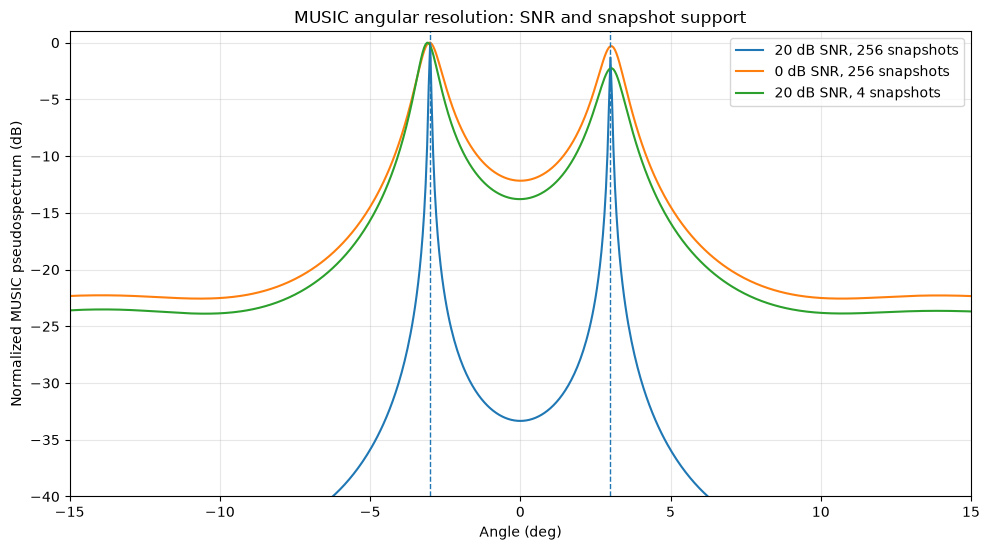

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MUSIC angular-resolution example
# ------------------------------------------------------------

M = 16
target_angles = [-3.0, 3.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)

n_sources = len(target_angles)


def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )


def music_spectrum(snr_db, n_snapshots, seed=1):

    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # Array manifold
    # ------------------------------------------------------------

    A = np.column_stack([
        steering(theta)
        for theta in target_angles
    ])

    # ------------------------------------------------------------
    # Source signals
    # ------------------------------------------------------------

    S = (
        rng.standard_normal((n_sources, n_snapshots))
        + 1j * rng.standard_normal(
            (n_sources, n_snapshots)
        )
    ) / np.sqrt(2)

    Xs = A @ S

    # ------------------------------------------------------------
    # Add noise
    # ------------------------------------------------------------

    noise_power = (
        np.mean(np.abs(Xs) ** 2)
        / 10 ** (snr_db / 10)
    )

    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    # ------------------------------------------------------------
    # Sample covariance matrix
    # ------------------------------------------------------------

    R = X @ X.conj().T / n_snapshots

    # ------------------------------------------------------------
    # Eigenvalue decomposition
    # ------------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(R)

    # Smallest M - n_sources eigenvectors
    # form the estimated noise subspace
    E_n = eigenvectors[:, :M - n_sources]

    # ------------------------------------------------------------
    # MUSIC pseudospectrum
    # ------------------------------------------------------------

    P = np.empty(angle_grid.size)

    for i, theta in enumerate(angle_grid):

        a = steering(theta)

        denominator = np.linalg.norm(
            E_n.conj().T @ a
        ) ** 2

        P[i] = 1.0 / max(
            denominator,
            np.finfo(float).eps
        )

    return 10 * np.log10(
        P / P.max()
    )


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.plot(
    angle_grid,
    music_spectrum(20, 256),
    label="20 dB SNR, 256 snapshots"
)

plt.plot(
    angle_grid,
    music_spectrum(0, 256),
    label="0 dB SNR, 256 snapshots"
)

plt.plot(
    angle_grid,
    music_spectrum(20, 4),
    label="20 dB SNR, 4 snapshots"
)

for theta in target_angles:
    plt.axvline(
        theta,
        linestyle="--",
        linewidth=1
    )

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized MUSIC pseudospectrum (dB)")
plt.title(
    "MUSIC angular resolution: SNR and snapshot support"
)

plt.xlim(-15, 15)
plt.ylim(-40, 1)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

With high SNR and sufficient snapshot support, MUSIC produces two sharp pseudospectrum peaks near the true target directions and clearly resolves the closely spaced sources.

Reducing the SNR increases perturbations of the covariance eigenspace and weakens the distinction between the signal and noise subspaces. Similarly, using only a few snapshots produces a poor covariance estimate, which can distort or merge the MUSIC peaks even when the SNR is high.

This demonstrates that MUSIC can achieve angular resolution beyond conventional beamforming limits, but only when the covariance matrix provides sufficiently accurate subspace information.

The angular-resolution behavior of MUSIC can be quantified using the **probability of resolution** rather than only inspecting individual pseudospectra.

The following Monte Carlo simulation considers a 16-element $\lambda/2$ ULA with two uncorrelated sources separated by $6^\circ$. Two target geometries are compared:

- a broadside pair at $-3^\circ$ and $+3^\circ$,
- an off-boresight pair at $42^\circ$ and $48^\circ$, centered at $45^\circ$.

For each SNR value, multiple independent signal and noise realizations are generated and the sample covariance matrix is eigendecomposed to estimate the MUSIC noise subspace. A trial is counted as resolved when the MUSIC pseudospectrum contains two distinct peaks and each estimated direction lies within half the target separation from the corresponding true direction.

The resulting probability of resolution is

$$
P_{\mathrm{res}}
=
\frac{N_{\mathrm{resolved}}}
     {N_{\mathrm{trials}}}.
$$

This provides a numerical measure of how reliably MUSIC separates two closely spaced sources as a function of SNR and steering direction.

Broadside:
SNR = -10.0 dB: P_res = 0.000
SNR =  -8.0 dB: P_res = 0.000
SNR =  -6.0 dB: P_res = 0.000
SNR =  -4.0 dB: P_res = 0.000
SNR =  -2.0 dB: P_res = 0.010
SNR =   0.0 dB: P_res = 0.083
SNR =   2.0 dB: P_res = 0.410
SNR =   4.0 dB: P_res = 0.820
SNR =   6.0 dB: P_res = 0.973
SNR =   8.0 dB: P_res = 1.000
SNR =  10.0 dB: P_res = 1.000
SNR =  12.0 dB: P_res = 1.000
SNR =  14.0 dB: P_res = 1.000
SNR =  16.0 dB: P_res = 1.000
SNR =  18.0 dB: P_res = 1.000
SNR =  20.0 dB: P_res = 1.000
SNR =  22.0 dB: P_res = 1.000
SNR =  24.0 dB: P_res = 1.000
SNR =  26.0 dB: P_res = 1.000
SNR =  28.0 dB: P_res = 1.000

Off-boresight:
SNR = -10.0 dB: P_res = 0.000
SNR =  -8.0 dB: P_res = 0.000
SNR =  -6.0 dB: P_res = 0.000
SNR =  -4.0 dB: P_res = 0.000
SNR =  -2.0 dB: P_res = 0.000
SNR =   0.0 dB: P_res = 0.000
SNR =   2.0 dB: P_res = 0.000
SNR =   4.0 dB: P_res = 0.010
SNR =   6.0 dB: P_res = 0.107
SNR =   8.0 dB: P_res = 0.397
SNR =  10.0 dB: P_res = 0.810
SNR =  12.0 dB: P_res = 0.990
SNR =  14.0 d

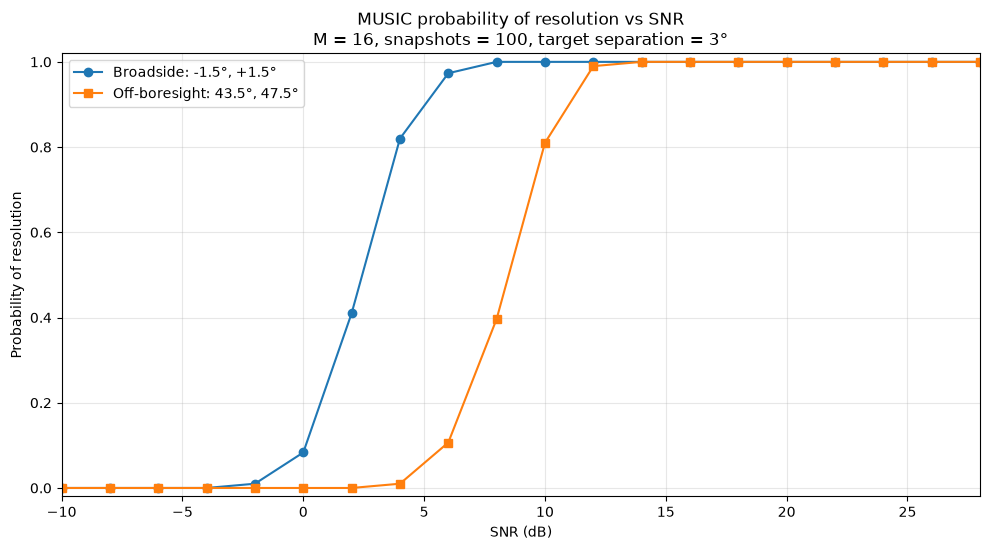

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MUSIC probability-of-resolution example
# ------------------------------------------------------------

M = 16
n_snapshots = 100
n_trials = 300

snr_db_values = np.arange(-10, 30, 2)

# Same physical angular separation in both scenarios
delta_theta = 3.0

target_angles_broadside = np.array([
    -delta_theta / 2,
    +delta_theta / 2
])

target_angles_off_boresight = np.array([
    45.0 - delta_theta / 2,
    45.0 + delta_theta / 2
])

n_sources = 2

m = np.arange(M)

# Fine spectral grid
angle_grid = np.linspace(-20, 70, 1801)

# ------------------------------------------------------------
# Steering vector
# ------------------------------------------------------------

def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )


# Precompute steering matrix for the complete scan grid
A_grid = np.column_stack([
    steering(theta)
    for theta in angle_grid
])

# ------------------------------------------------------------
# MUSIC pseudospectrum
# ------------------------------------------------------------

def music_spectrum(
    target_angles,
    snr_db,
    n_snapshots,
    rng
):
    # Source steering matrix
    A = np.column_stack([
        steering(theta)
        for theta in target_angles
    ])

    # Two independent complex Gaussian source signals
    S = (
        rng.standard_normal(
            (n_sources, n_snapshots)
        )
        + 1j * rng.standard_normal(
            (n_sources, n_snapshots)
        )
    ) / np.sqrt(2)

    # Noise-free received snapshots
    Xs = A @ S

    # Noise power for requested array SNR
    signal_power = np.mean(
        np.abs(Xs) ** 2
    )

    noise_power = (
        signal_power
        / 10 ** (snr_db / 10)
    )

    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    X = Xs + noise

    # Sample covariance matrix
    R = X @ X.conj().T / n_snapshots

    # --------------------------------------------------------
    # Eigenvalue decomposition
    # --------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(R)

    # np.linalg.eigh returns eigenvalues in ascending order.
    # The M - n_sources eigenvectors associated with the
    # smallest eigenvalues form the noise subspace.
    E_n = eigenvectors[:, :M - n_sources]

    # --------------------------------------------------------
    # MUSIC pseudospectrum
    # --------------------------------------------------------

    noise_projection = E_n @ E_n.conj().T

    denominator = np.real(
        np.sum(
            A_grid.conj()
            * (noise_projection @ A_grid),
            axis=0
        )
    )

    P = 1.0 / np.maximum(
        denominator,
        np.finfo(float).eps
    )

    return P


# ------------------------------------------------------------
# Local-maximum detection
# ------------------------------------------------------------

def find_local_peaks(P):
    """
    Return indices of all strict local maxima.
    """

    return np.where(
        (P[1:-1] > P[:-2])
        & (P[1:-1] > P[2:])
    )[0] + 1


# ------------------------------------------------------------
# Resolution criterion
# ------------------------------------------------------------

def is_resolved(P, target_angles):
    """
    Resolution criterion:

    1. Two distinct pseudospectrum peaks must exist.
    2. One peak must correspond to each target.
    3. Each peak must be within delta_theta / 2
       of its true target direction.
    """

    peak_indices = find_local_peaks(P)

    if len(peak_indices) < 2:
        return False

    peak_angles = angle_grid[peak_indices]
    peak_values = P[peak_indices]

    # Restrict attention to the angular interval around
    # the two targets to reject distant sidelobes or
    # noise-induced peaks.
    margin = delta_theta / 2

    search_min = target_angles[0] - margin
    search_max = target_angles[1] + margin

    valid = (
        (peak_angles >= search_min)
        & (peak_angles <= search_max)
    )

    peak_angles = peak_angles[valid]
    peak_values = peak_values[valid]

    if len(peak_angles) < 2:
        return False

    # Sort candidate peaks by pseudospectrum magnitude
    order = np.argsort(
        peak_values
    )[::-1]

    peak_angles = peak_angles[order]

    # Take the two strongest candidate peaks
    estimated_angles = np.sort(
        peak_angles[:2]
    )

    true_angles = np.sort(
        target_angles
    )

    # Each estimate must lie within half
    # the target separation
    tolerance = delta_theta / 2

    return np.all(
        np.abs(
            estimated_angles
            - true_angles
        ) <= tolerance
    )


# ------------------------------------------------------------
# Monte Carlo probability of resolution
# ------------------------------------------------------------

def probability_of_resolution(
    target_angles,
    snr_db_values,
    n_trials,
    seed
):
    rng = np.random.default_rng(seed)

    probabilities = []

    for snr_db in snr_db_values:

        resolved_count = 0

        for _ in range(n_trials):

            P = music_spectrum(
                target_angles,
                snr_db,
                n_snapshots,
                rng
            )

            if is_resolved(
                P,
                target_angles
            ):
                resolved_count += 1

        probability = (
            resolved_count
            / n_trials
        )

        probabilities.append(
            probability
        )

        print(
            f"SNR = {snr_db:5.1f} dB: "
            f"P_res = {probability:.3f}"
        )

    return np.array(probabilities)


# ------------------------------------------------------------
# Run simulations
# ------------------------------------------------------------

print("Broadside:")

p_res_broadside = probability_of_resolution(
    target_angles_broadside,
    snr_db_values,
    n_trials,
    seed=1
)

print("\nOff-boresight:")

p_res_off_boresight = probability_of_resolution(
    target_angles_off_boresight,
    snr_db_values,
    n_trials,
    seed=2
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.plot(
    snr_db_values,
    p_res_broadside,
    marker="o",
    label="Broadside: -1.5°, +1.5°"
)

plt.plot(
    snr_db_values,
    p_res_off_boresight,
    marker="s",
    label="Off-boresight: 43.5°, 47.5°"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Probability of resolution")

plt.title(
    "MUSIC probability of resolution vs SNR\n"
    f"M = {M}, snapshots = {n_snapshots}, "
    f"target separation = {delta_theta:.0f}°"
)

plt.xlim(
    snr_db_values[0],
    snr_db_values[-1]
)

plt.ylim(-0.02, 1.02)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

The probability of resolution increases with SNR because the sample covariance matrix provides a progressively more accurate estimate of the signal and noise subspaces. Once the eigenspaces are sufficiently well separated, MUSIC reliably produces two distinct pseudospectrum peaks near the true source directions.

The broadside configuration generally provides better resolution than the off-boresight configuration for the same physical angular separation. For a $\lambda/2$ ULA, the array manifold is uniform in spatial frequency,

$$
u = \sin\theta,
$$

rather than in angle. Therefore, the same angular separation corresponds to a smaller separation in spatial frequency at larger steering angles,

$$
\Delta u
\approx
\cos\theta\,\Delta\theta.
$$

Consequently, the two off-boresight steering vectors are more similar, making subspace separation more difficult and requiring a higher SNR to achieve the same probability of resolution.

The result illustrates that MUSIC can provide very high angular resolution, but its practical resolving capability remains dependent on SNR, snapshot support, and target direction.

The MUSIC implementation is validated using real measurements acquired with the **AWR2243** radar in two-target broadside and off-boresight scenarios. For comparison, the MUSIC pseudospectrum is shown together with the Capon/MVDR spectrum using the same covariance snapshots and Forward–Backward averaging.

<p align="center">
  <img
    src="../docs/images/mus_vs_cap_broadside.png"
    alt="Capon and MUSIC comparison for the broadside scenario"
    width="95%">
</p>

<p align="center">
  <img
    src="../docs/images/mus_vs_cap_off_boresight.png"
    alt="Capon and MUSIC comparison for the off-boresight scenario"
    width="95%">
</p>


Both Capon/MVDR and MUSIC produce sharp, narrow peaks at nearly the same target directions in the broadside and off-boresight measurements.

The main difference is visible away from the target peaks. The MUSIC pseudospectrum has a more uniform background level, whereas the Capon/MVDR spectrum shows stronger variation and additional structure across the scan region.

Despite their different formulations, both methods provide consistent DoA estimates and clearly resolve the two corner reflectors in both measurement scenarios.


<a id="doa-estimation-accuracy"></a>

### DoA Estimation Accuracy

MUSIC estimates Direction of Arrival from the signal and noise subspaces of the sample covariance matrix. With a limited number of snapshots, the covariance estimate contains finite-sample errors, which perturb the eigenvectors and therefore the estimated noise subspace.

As the number of snapshots increases, the sample covariance matrix approaches its statistical expectation, improving the separation between the signal and noise subspaces and reducing the variance of the estimated DoA.

The following Monte Carlo experiment evaluates the MUSIC DoA RMSE as a function of snapshot support for two SNR levels.

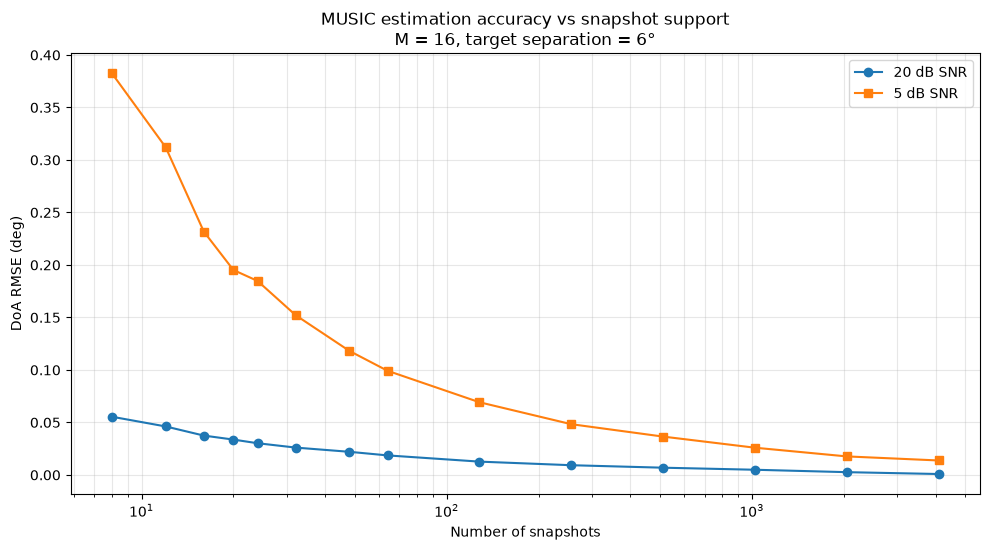

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# MUSIC RMSE versus number of snapshots
# ------------------------------------------------------------

M = 16
n_trials = 300

snapshot_values = np.array([
    8, 12, 16, 20, 24, 32, 48, 64,
    128, 256, 512, 1024, 2048, 4096
])

snr_values = [20, 5]

delta_theta = 6.0
target_angles = np.array([
    -delta_theta / 2,
    +delta_theta / 2
])

n_sources = len(target_angles)

m = np.arange(M)
angle_grid = np.linspace(-10, 10, 1601)


def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )


A_grid = np.column_stack([
    steering(theta) for theta in angle_grid
])


def estimate_doa(n_snapshots, snr_db, rng):

    A = np.column_stack([
        steering(theta) for theta in target_angles
    ])

    # ------------------------------------------------------------
    # Source signals
    # ------------------------------------------------------------

    S = (
        rng.standard_normal((n_sources, n_snapshots))
        + 1j * rng.standard_normal(
            (n_sources, n_snapshots)
        )
    ) / np.sqrt(2)

    Xs = A @ S

    # ------------------------------------------------------------
    # Add noise
    # ------------------------------------------------------------

    noise_power = (
        np.mean(np.abs(Xs) ** 2)
        / 10 ** (snr_db / 10)
    )

    X = Xs + np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    # ------------------------------------------------------------
    # Sample covariance matrix
    # ------------------------------------------------------------

    R = X @ X.conj().T / n_snapshots

    # ------------------------------------------------------------
    # Eigenvalue decomposition
    # ------------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(R)

    # np.linalg.eigh returns eigenvalues in ascending order.
    # The M - n_sources smallest-eigenvalue eigenvectors
    # span the noise subspace.
    E_n = eigenvectors[:, :M - n_sources]

    # ------------------------------------------------------------
    # MUSIC pseudospectrum
    # ------------------------------------------------------------

    noise_projection = E_n @ E_n.conj().T

    denominator = np.real(
        np.sum(
            A_grid.conj()
            * (noise_projection @ A_grid),
            axis=0
        )
    )

    P = 1.0 / np.maximum(
        denominator,
        np.finfo(float).eps
    )

    # ------------------------------------------------------------
    # Peak detection
    # ------------------------------------------------------------

    peaks = np.where(
        (P[1:-1] > P[:-2])
        & (P[1:-1] > P[2:])
    )[0] + 1

    if len(peaks) < n_sources:
        return None

    strongest = peaks[
        np.argsort(P[peaks])[-n_sources:]
    ]

    return np.sort(
        angle_grid[strongest]
    )


def rmse_vs_snapshots(snr_db, seed):

    rng = np.random.default_rng(seed)
    rmse = []

    for n_snapshots in snapshot_values:

        errors = []

        for _ in range(n_trials):

            est = estimate_doa(
                n_snapshots,
                snr_db,
                rng
            )

            if est is not None:
                errors.extend(
                    est - target_angles
                )

        rmse.append(
            np.sqrt(
                np.mean(np.square(errors))
            )
            if errors
            else np.nan
        )

    return np.array(rmse)


rmse_20 = rmse_vs_snapshots(
    snr_values[0],
    seed=1
)

rmse_5 = rmse_vs_snapshots(
    snr_values[1],
    seed=2
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.6))

plt.semilogx(
    snapshot_values,
    rmse_20,
    "o-",
    label=f"{snr_values[0]} dB SNR"
)

plt.semilogx(
    snapshot_values,
    rmse_5,
    "s-",
    label=f"{snr_values[1]} dB SNR"
)

plt.xlabel("Number of snapshots")
plt.ylabel("DoA RMSE (deg)")

plt.title(
    "MUSIC estimation accuracy vs snapshot support\n"
    f"M = {M}, target separation = {delta_theta:.0f}°"
)

plt.grid(
    True,
    which="both",
    alpha=0.3
)

plt.legend()
plt.tight_layout()
plt.show()

The MUSIC estimation error decreases as the number of snapshots increases because the sample covariance matrix becomes more accurate and the estimated noise subspace approaches its ideal orientation.

At high SNR, relatively few snapshots may already provide a well-separated eigenspace and low DoA error. At lower SNR, substantially more snapshots are required because noise produces stronger perturbations of the covariance eigenvectors and reduces the separation between the signal and noise subspaces.

The experiment therefore illustrates an important practical property of MUSIC: its DoA accuracy depends not only on SNR and angular separation, but also on the amount of statistical support available for covariance estimation.

<a id="model-mismatch"></a>

### Model Mismatch

MUSIC relies directly on the assumed array steering-vector model. In practice, antenna-position errors, channel phase offsets, mutual coupling, and imperfect calibration can cause the true array response to differ from the ideal model used by the estimator.

For an ideal model, a true steering vector satisfies

$$
\mathbf{E}_n^H \mathbf{a}(\theta_k) \approx \mathbf{0}.
$$

With array-model mismatch, the received data are generated by a perturbed steering vector, while MUSIC still evaluates the ideal steering vector. The orthogonality condition is therefore violated, which can distort the MUSIC pseudospectrum and bias the estimated DoA.

The following example introduces independent phase errors across the antenna elements while MUSIC continues to use the ideal ULA model.

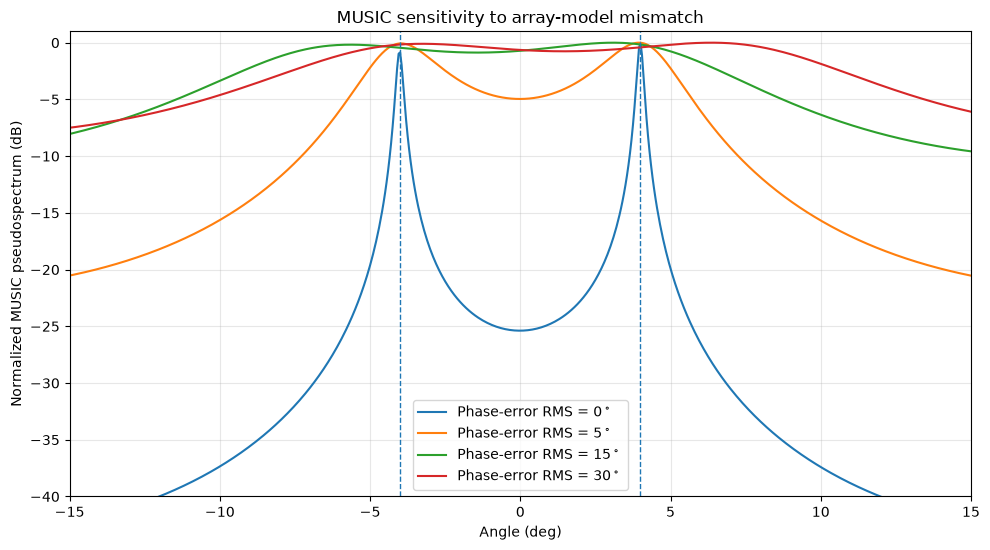

In [9]:
import numpy as np
import matplotlib.pyplot as plt

M = 8
target_angles = [-4.0, 4.0]
angle_grid = np.linspace(-20, 20, 801)
m = np.arange(M)
rng = np.random.default_rng(4)

def steering(theta):
    return np.exp(
        1j * np.pi * m * np.sin(np.deg2rad(theta))
    )

def music_with_mismatch(phase_rms_deg):
    L = 256
    snr_db = 20.0
    n_sources = len(target_angles)

    # ------------------------------------------------------------
    # Array-model mismatch
    # ------------------------------------------------------------

    phase_err = np.deg2rad(
        rng.normal(0.0, phase_rms_deg, M)
    )

    D = np.diag(
        np.exp(1j * phase_err)
    )

    # True array manifold contains phase errors
    A_true = np.column_stack(
        [D @ steering(theta) for theta in target_angles]
    )

    # ------------------------------------------------------------
    # Source signals
    # ------------------------------------------------------------

    S = (
        rng.standard_normal((n_sources, L))
        + 1j * rng.standard_normal((n_sources, L))
    ) / np.sqrt(2)

    Xs = A_true @ S

    # ------------------------------------------------------------
    # Add noise
    # ------------------------------------------------------------

    noise_power = (
        np.mean(np.abs(Xs) ** 2)
        / 10 ** (snr_db / 10)
    )

    noise = np.sqrt(noise_power / 2) * (
        rng.standard_normal(Xs.shape)
        + 1j * rng.standard_normal(Xs.shape)
    )

    X = Xs + noise

    # ------------------------------------------------------------
    # Sample covariance matrix
    # ------------------------------------------------------------

    R = X @ X.conj().T / L

    # ------------------------------------------------------------
    # Eigenvalue decomposition
    # ------------------------------------------------------------

    eigenvalues, eigenvectors = np.linalg.eigh(R)

    # np.linalg.eigh returns eigenvalues in ascending order
    noise_subspace = eigenvectors[:, :M - n_sources]

    # ------------------------------------------------------------
    # MUSIC pseudospectrum
    # ------------------------------------------------------------

    P = np.empty(angle_grid.size)

    for i, theta in enumerate(angle_grid):

        a = steering(theta)

        projection = (
            a.conj()
            @ noise_subspace
            @ noise_subspace.conj().T
            @ a
        )

        P[i] = 1.0 / np.abs(projection)

    return 10 * np.log10(P / P.max())


plt.figure(figsize=(10, 5.6))

for phase_rms in [0, 5, 15, 30]:

    plt.plot(
        angle_grid,
        music_with_mismatch(phase_rms),
        label=rf"Phase-error RMS = {phase_rms}$^\circ$"
    )

for theta in target_angles:
    plt.axvline(
        theta,
        linestyle="--",
        linewidth=1
    )

plt.xlabel("Angle (deg)")
plt.ylabel("Normalized MUSIC pseudospectrum (dB)")
plt.title("MUSIC sensitivity to array-model mismatch")
plt.xlim(-15, 15)
plt.ylim(-40, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

With an ideal array model, the two target steering vectors are nearly orthogonal to the estimated noise subspace and produce sharp MUSIC peaks at the true directions.

As the antenna phase mismatch increases, this orthogonality is progressively violated. The pseudospectrum peaks become displaced and less distinct, and sufficiently large mismatch can significantly degrade angular resolution and DoA accuracy.

This illustrates an important practical limitation of MUSIC: its super-resolution capability depends not only on SNR and the covariance estimate, but also on accurate knowledge of the array manifold. Antenna calibration therefore becomes particularly important for practical MUSIC implementations.